Antes de tudo, primeiro precisamos montar o


In [3]:
from google.colab import drive
import os
import pandas as pd
import shutil
from datetime import datetime

drive.mount('/content/drive')

# @title ⚙️ Clique no "Play" para carregar as funções base

# -------
def contar_arquivos(caminho_pasta):
  """
  Vasculha a pasta do drive e retorna a quantidade de arquivos dentro dela
  """
  # 1 Vasculha o diretório fornecido atras de arquivos
  with os.scandir(caminho_pasta) as arquivos: # Usa o with para não deixar arquivos abertos na memória
    soma = 0
    for arquivo in arquivos:
      # 2. Se é um arquivo soma + 1
      if arquivo.is_file() and arquivo.name.endswith(".pdf"): # É um arquivo e é um .pdf
        soma += 1
  return soma
# -------
# -------
def pega_nomes_pasta(caminho_pasta):
  """
  Pega todos os nomes dos arquivos dentro de uma pasta
  """
  lista_nomes = [] # Lista vasia onde sera adiciona os nomes dos arquivos
  with os.scandir(caminho_pasta) as dados: # Pega os dados da pasta para inteira um a um
    for dado in dados: # Passa por cada arquivo ou diretório
      if dado.is_file() and dado.name.endswith(".pdf"): # O dado é um arquivo e termina com .pdf
        lista_nomes.append(dado.name) # Adiciona o nome do arquivo na lista
  return lista_nomes
# -------

# -------
def pega_nomes_planilha(caminho_arquivo):
  """
  Pega todos os nomes da coluna de uma planilha
  """
  df = pd.read_excel(caminho_arquivo) # Lê o arquivo excel
  coluna_dados = df.iloc[:, 0] # Pega a primeira coluna
  lista_nomes = []

  for item in coluna_dados:

    if pd.isna(item) == False: # Se o item não for nulo
      nome_texto = str(item) # Converte o item para string
      nome_limpo = nome_texto.strip() # Retira possiveis espaços
      nome_completo = f"{nome_limpo}.pdf" # Adiciona um .pdf ao final do nome para futuras comparações
      lista_nomes.append(nome_completo) # Adiciona o item na lista

  return lista_nomes
# -------

# -------
def comparar_listas(lista_01, lista_02):
  """
  Compara duas listas e retorna os itens que estão na primeira lista e não estão na segunda
  """
  # 1. Transforma a lista em conjutos
  conjunto_01 = set(lista_01)
  conjunto_02 = set(lista_02)

  # 2. Usa o operador de subtração
  diferenca = conjunto_01 - conjunto_02

  # 3. Transforma a diferença em lista
  lista_diferenca = list(diferenca)

  # 4. Retorna a lista com nome de arquivos que estão na lista_01 e não estão na lista_02
  return lista_diferenca
# -------

# -------
def salvar_relatorio(lista_faltantes_ida, lista_diferenca_volta, pasta_saida):
  """
  Exibe um resumo na tela e salva a lista completa em um arquivo .txt no Drive
  """

  # 1. Se não houver nomes faltantes, encerra a função
  if len(lista_diferenca_ida) == 0 and len(lista_diferenca_volta) == 0:
    print("Todos os arquivos da planilha estão na pasta do drive.")
    return

  # 2. Prepara o nome do arquivo com a data e hora
  agora = datetime.now()
  data_hora = agora.strftime("%Y-%m-%d_%H-%M-%S")
  nome_arquivo = f"relatorio_{data_hora}.txt"
  caminho_completo = os.path.join(pasta_saida, nome_arquivo)

  # 3. Salvar a lista completa no drive
  with open(caminho_completo, "w") as arquivo_txt:

    # Separando informações
    # Lista diferença nomes planilha vs arquinos na pasta
    arquivo_txt.write("Lista de nomes de arquivos que estão na planilha e não estão na pasta do drive:\n")
    for nome in lista_diferenca_ida:
      arquivo_txt.write(nome + "\n")

    # Lista diferença arquivos na pasta vs nomes planilha
    arquivo_txt.write("\nLista de nomes de arquivos que estão na pasta do drive e não estão na planilha:\n")
    for nome in lista_diferenca_volta:
      arquivo_txt.write(nome + "\n")

  # 4. Exibe um resumo visual
  print("Atenção: Foram encontrados arquivos faltantes.")
  print(f"Total de itens não encontrado: {len(lista_diferenca_ida) + len(lista_diferenca_volta)}")
  print(f"Total de itens na planilha: {len(lista_diferenca_ida)}")
  print(f"Total de itens na pasta do drive: {len(lista_diferenca_volta)}")
  print(f"Arquivo salvo em: {caminho_completo}")
  print(f"O {nome_arquivo} pode levar até 1 minuto para aparecer no drive")
# -------

# -------
def move_arquivos(pasta_origem, pasta_destino):
  """
  Move os arquivos .pdf da pasta de origem para a pasta de destino.
  Retorna a quantidade de arquivos movidos.
  """

  # 1. Verifica se a pasta de destino existe, se não , cria ela
  if not os.path.exists(pasta_destino):
    os.makedirs(pasta_destino)

  # 2. Vasculha a pasta de origem
  with os.scandir(pasta_origem) as arquivos:

    soma = 0
    for arquivo in arquivos:

      # 3. Verifica se é um arquivo e se é PDF
      if arquivo.is_file() and arquivo.name.endswith(".pdf"):

        # Define os caminhos completos
        caminho_origem = os.path.join(pasta_origem, arquivo.name)
        caminho_destino = os.path.join(pasta_destino, arquivo.name)

        # Move o arquivo
        shutil.move(caminho_origem, caminho_destino)
        print(f"{arquivo.name} movido ✅")
        soma += 1

  # 5. Retorna a soma de arquivos movidos
  return soma
# -------


# Contar quantos arquivos .pdf contem em um ditretório
Basta colar o caminho da pasta no lugar indicado.

In [5]:
# @title Contar quantos arquivos .pdf contem um diretório.
caminho_da_pasta = "/content/drive/MyDrive/testes/teste2" # @param {type:"string"}

# 1. Chama a função que devolve o valores de arquivos .pdf
soma = contar_arquivos(caminho_da_pasta)

# 2. Exibe o resultado
print(f"A pasta contém {soma} arquivos .pdf")

A pasta contém 9 arquivos .pdf


# Verificar se existe arquivos na planilha que não estão no diretório do drive (e viceversa)

Aqui basta colar o caminho da pasta que quer verificar e colar o caminho da planilha que contem os nomes dos arquivos

A planilha deve conter apenas os dados na primeira coluna como o exemplo a baixo:
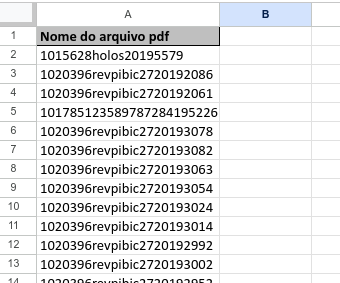

In [23]:
# @title Checar duas listas de nomes e devolver uma lista com a diferença
# 1. Pega os caminhos da planilha e do diretório a ser checado
caminho_da_pasta = "/content/drive/MyDrive/testes" # @param {type:"string"}
caminho_da_planilha = "/content/drive/MyDrive/testes/nomes_planilha.xlsx" # @param {type:"string"}
caminho_txt = os.path.dirname(caminho_da_pasta) # Salva o .txt na mesma pasta da planilha

# 2. Pegar as informações de cada lista de nomes
lista_nomes_planilha = pega_nomes_planilha(caminho_da_planilha)
lista_nomes_pasta = pega_nomes_pasta(caminho_da_pasta)

# 3. Compara as listas e devolve duas listas
lista_diferenca_ida = comparar_listas(lista_nomes_planilha, lista_nomes_pasta)
lista_diferenca_volta = comparar_listas(lista_nomes_pasta, lista_nomes_planilha)

# 4. Salvando relatorio e exibindo algumas informações
salvar_relatorio(lista_diferenca_ida, lista_diferenca_volta, caminho_da_pasta)



Atenção: Foram encontrados arquivos faltantes.
Total de itens não encontrado: 147
Total de itens na planilha: 138
Total de itens na pasta do drive: 9
Arquivo salvo em: /content/drive/MyDrive/testes/relatorio_2026-04-20_20-02-58.txt
O relatorio_2026-04-20_20-02-58.txt pode levar até 1 minuto para aparecer no drive


# Mover arquivos PDFs de uma pasta de origem para uma pasta de destino
Basta colar o caminho da pasta de origem e o caminho da pasta de destino que todos os pdfs serão movidos.


In [27]:
# @title Mover Arquivos PDF entre Pastas
# @markdown Informe os caminhos completos do seu Google Drive.

origem = "/content/drive/MyDrive/testes" # @param {type:"string"}
destino = "/content/drive/MyDrive/testes/teste2" # @param {type:"string"}

# Botão para executar a ação
if origem != "" and destino != "":
  print(f"Iniciando movimentação de {origem} para {destino}...")
  total = move_arquivos(origem, destino)
  print(f"✅ Operação concluída!")
  print(f"Foram movidos {total} arquivos com sucesso.")
else:
  print("⚠️ Por favor, preencha os dois caminhos acima.")

Iniciando movimentação de /content/drive/MyDrive/testes para /content/drive/MyDrive/testes/teste2...
Cópia de Parte 6 - ME115.pdf movido ✅
Cópia de Parte 5 - ME115.pdf movido ✅
Cópia de Parte 4 - ME115.pdf movido ✅
Cópia de Parte 3 - ME115.pdf movido ✅
Cópia de Parte 2 à 6 - ME115.pdf movido ✅
Cópia de Parte 2 - ME115.pdf movido ✅
Cópia de Parte 1 à 6 - ME115.pdf movido ✅
Cópia de Parte 1 - ME115.pdf movido ✅
Cópia de Parte 7 - ME115.pdf movido ✅
✅ Operação concluída!
Foram movidos 9 arquivos com sucesso.


# Explicações de uso para os scripts

A baixo você encontrar uma breve explicação de uso para os scripts aqui feitos

# Pegar o `caminho` de uma pasta ou arquivo
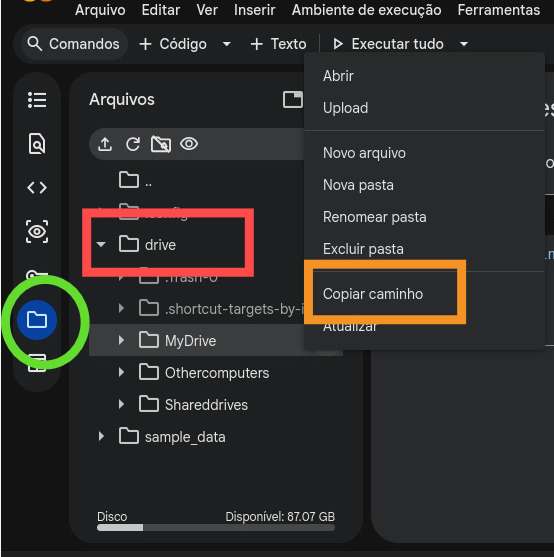

**Explicações:**
1. Ao montar o drive, o que aconte logo ao rodar o bloco de códido principal no canto direito aparecerá esse icone circulado em verde **(clique nele)**

2. Entre os diretórios que aparecerá na janela `Arquivos`, temos o `drive`, que contem entre outras:
  - **MyDrive:** Drive pessoal principal.
  - **Shareddriver:** Drives compartilhados com você.

3. Ao clicar sobre um diretório ou arquivo na lista com o botão direito do mouse e depois em `Copiar caminho`, você copia o caminho completo do arquivo ou diretório que são pedidos ao usar os scripts.